# 1. Импорт библиотек

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = (10, 6)
sns.set(style='whitegrid')

# 2. Проверка рабочей папки и файлов

In [5]:
print("Текущая рабочая директория:")
print(os.getcwd())

print("\nФайлы в текущей директории:")
print(os.listdir())

Текущая рабочая директория:
/content

Файлы в текущей директории:
['.config', '.ipynb_checkpoints', 'googleplaystore.csv', 'sample_data']


# 3. Загрузка данных

In [6]:
file_name = "googleplaystore.csv"
df = pd.read_csv(file_name)

print("Файл успешно загружен.")
display(df.head())

Файл успешно загружен.


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


# 4. Первичный анализ данных

In [7]:
print("Размер датасета:")
print(df.shape)

print("\nНазвания столбцов:")
print(df.columns)

print("\nТипы данных:")
print(df.dtypes)

print("\nКоличество пропусков по столбцам:")
print(df.isnull().sum())

Размер датасета:
(10841, 13)

Названия столбцов:
Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

Типы данных:
App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

Количество пропусков по столбцам:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


# 5. Общая статистика

In [8]:
display(df.describe(include="all"))

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 6. Создание рабочей копии

In [9]:
data = df.copy()

# 7. Очистка и преобразование числовых признаков

In [10]:
# Удаляем полные дубликаты
data = data.drop_duplicates()

# Rating -> числовой тип
data["Rating"] = pd.to_numeric(data["Rating"], errors="coerce")

# Reviews -> числовой тип
data["Reviews"] = pd.to_numeric(data["Reviews"], errors="coerce")

# Installs: убираем '+' и ','
data["Installs"] = data["Installs"].astype(str)
data["Installs"] = data["Installs"].str.replace("+", "", regex=False)
data["Installs"] = data["Installs"].str.replace(",", "", regex=False)
data["Installs"] = pd.to_numeric(data["Installs"], errors="coerce")

# Price: убираем '$'
data["Price"] = data["Price"].astype(str)
data["Price"] = data["Price"].str.replace("$", "", regex=False)
data["Price"] = pd.to_numeric(data["Price"], errors="coerce")

# Size: переводим в мегабайты
def convert_size(size_value):
    size_value = str(size_value)

    if size_value == "Varies with device":
        return np.nan
    elif "M" in size_value:
        return float(size_value.replace("M", ""))
    elif "k" in size_value:
        return float(size_value.replace("k", "")) / 1024
    else:
        return np.nan

data["Size"] = data["Size"].apply(convert_size)

print("Пропуски после преобразования числовых признаков:")
print(data[["Rating", "Reviews", "Installs", "Price", "Size"]].isnull().sum())

Пропуски после преобразования числовых признаков:
Rating      1465
Reviews        1
Installs       1
Price          1
Size        1527
dtype: int64


# 8. Проверка категориальных признаков

In [11]:
categorical_columns = ["Category", "Type", "Content Rating", "Genres"]

for col in categorical_columns:
    print(f"\nСтолбец: {col}")
    print("Количество пропусков:", data[col].isnull().sum())
    print("Количество уникальных значений:", data[col].nunique())
    print("Примеры значений:", data[col].dropna().unique()[:10])


Столбец: Category
Количество пропусков: 0
Количество уникальных значений: 34
Примеры значений: ['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT']

Столбец: Type
Количество пропусков: 1
Количество уникальных значений: 3
Примеры значений: ['Free' 'Paid' '0']

Столбец: Content Rating
Количество пропусков: 1
Количество уникальных значений: 6
Примеры значений: ['Everyone' 'Teen' 'Everyone 10+' 'Mature 17+' 'Adults only 18+' 'Unrated']

Столбец: Genres
Количество пропусков: 0
Количество уникальных значений: 120
Примеры значений: ['Art & Design' 'Art & Design;Pretend Play' 'Art & Design;Creativity'
 'Art & Design;Action & Adventure' 'Auto & Vehicles' 'Beauty'
 'Books & Reference' 'Business' 'Comics' 'Comics;Creativity']


# 9. Удаление строк с пропусками

In [12]:
data = data.dropna(axis=0, how="any")

print("Размер датасета после удаления строк с пропусками:")
print(data.shape)

display(data.head())

Размер датасета после удаления строк с пропусками:
(7418, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


# 10. Кодирование категориальных признаков

In [13]:
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = data[col].astype(str)
    data[col + "_encoded"] = le.fit_transform(data[col])
    label_encoders[col] = le

print("Данные после кодирования категориальных признаков:")
display(data.head())

Данные после кодирования категориальных признаков:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Category_encoded,Type_encoded,Content Rating_encoded,Genres_encoded
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0,0,1,9
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0,0,1,11
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0,0,1,9
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0,0,4,9
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0,0,1,10


# 11. Формирование таблицы для корреляционного анализа

In [14]:
corr_data = data[
    [
        "Rating",
        "Reviews",
        "Size",
        "Installs",
        "Price",
        "Category_encoded",
        "Type_encoded",
        "Content Rating_encoded",
        "Genres_encoded"
    ]
]

print("Таблица признаков для корреляционного анализа:")
display(corr_data.head())

Таблица признаков для корреляционного анализа:


,Rating,Reviews,Size,Installs,Price,Category_encoded,Type_encoded,Content Rating_encoded,Genres_encoded
0,4.1,159.0,19.0,10000.0,0.0,0,0,1,9
1,3.9,967.0,14.0,500000.0,0.0,0,0,1,11
2,4.7,87510.0,8.7,5000000.0,0.0,0,0,1,9
3,4.5,215644.0,25.0,50000000.0,0.0,0,0,4,9
4,4.3,967.0,2.8,100000.0,0.0,0,0,1,10


# 12. Корреляционная матрица

In [15]:
corr_matrix = corr_data.corr(method="pearson")

print("Корреляционная матрица:")
display(corr_matrix)

Корреляционная матрица:


,Rating,Reviews,Size,Installs,Price,Category_encoded,Type_encoded,Content Rating_encoded,Genres_encoded
Rating,1.000000,0.080456,0.081874,0.054350,-0.021941,-0.050928,0.038993,0.032444,-0.057692
Reviews,0.080456,1.000000,0.240068,0.632032,-0.010015,-0.017678,-0.043909,0.043711,-0.035955
Size,0.081874,0.240068,1.000000,0.166979,-0.026855,-0.152357,-0.026266,0.200574,-0.144710
Installs,0.054350,0.632032,0.166979,1.000000,-0.010627,-0.002572,-0.047111,0.044926,-0.063298
Price,-0.021941,-0.010015,-0.026855,-0.010627,1.000000,-0.014604,0.223957,-0.012835,-0.003265
Category_encoded,-0.050928,-0.017678,-0.152357,-0.002572,-0.014604,1.000000,0.025536,-0.113605,0.751191
Type_encoded,0.038993,-0.043909,-0.026266,-0.047111,0.223957,0.025536,1.000000,-0.034530,0.004229
Content Rating_encoded,0.032444,0.043711,0.200574,0.044926,-0.012835,-0.113605,-0.034530,1.000000,-0.158038
Genres_encoded,-0.057692,-0.035955,-0.144710,-0.063298,-0.003265,0.751191,0.004229,-0.158038,1.000000


# 13. Тепловая карта корреляции

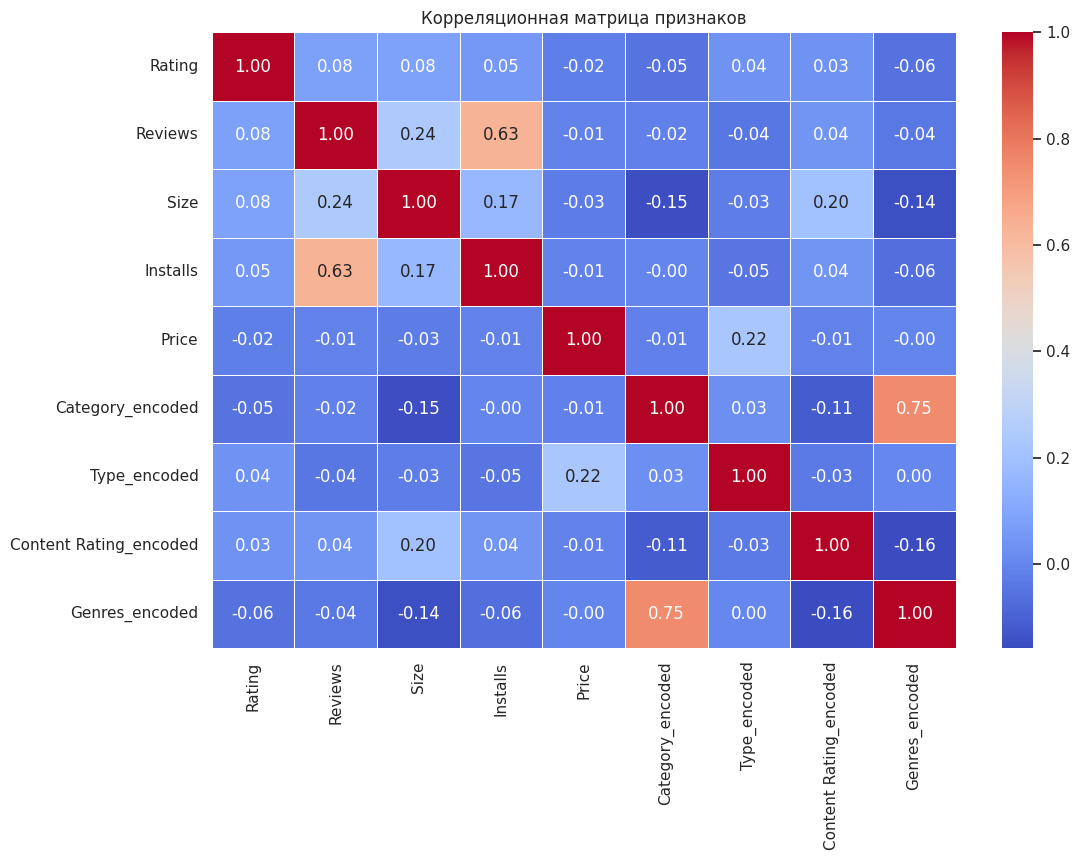

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Корреляционная матрица признаков")
plt.show()

# 14. Диаграмма рассеяния

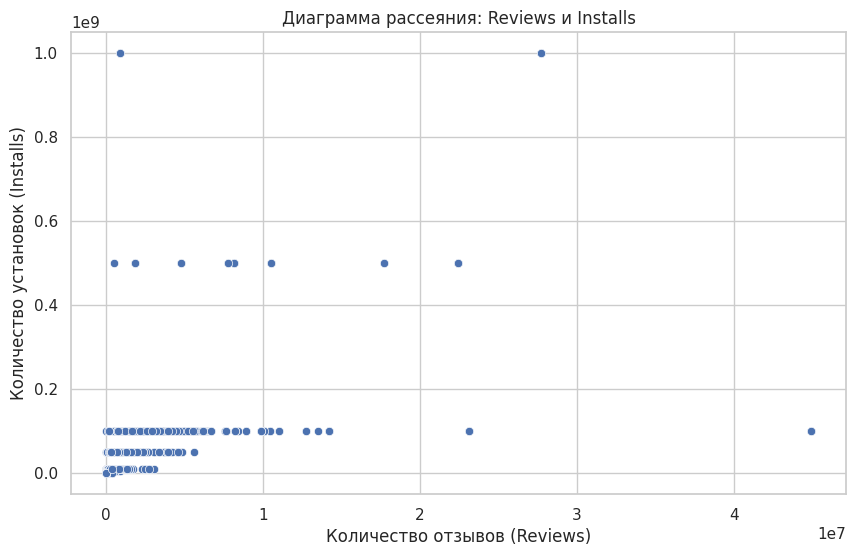

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x="Reviews", y="Installs")
plt.title("Диаграмма рассеяния: Reviews и Installs")
plt.xlabel("Количество отзывов (Reviews)")
plt.ylabel("Количество установок (Installs)")
plt.show()

# 15. Поиск самых сильных корреляций

In [20]:
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)

# Убираем корреляцию признака с самим собой
corr_pairs = corr_pairs[corr_pairs < 1]

print("Наиболее сильные корреляции между признаками:")
print(corr_pairs.head(15))

Наиболее сильные корреляции между признаками:
Category_encoded        Genres_encoded            0.751191
Genres_encoded          Category_encoded          0.751191
Installs                Reviews                   0.632032
Reviews                 Installs                  0.632032
                        Size                      0.240068
Size                    Reviews                   0.240068
Type_encoded            Price                     0.223957
Price                   Type_encoded              0.223957
Size                    Content Rating_encoded    0.200574
Content Rating_encoded  Size                      0.200574
Size                    Installs                  0.166979
Installs                Size                      0.166979
Rating                  Size                      0.081874
Size                    Rating                    0.081874
Rating                  Reviews                   0.080456
dtype: float64


# 16. Искусственные пропуски

In [21]:
data_artificial = df.copy()

np.random.seed(42)
random_indices = data_artificial.sample(frac=0.03).index
data_artificial.loc[random_indices, "Rating"] = np.nan

print("Количество пропусков после искусственного добавления:")
print(data_artificial.isnull().sum())

Количество пропусков после искусственного добавления:
App                  0
Category             0
Rating            1750
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


# 17. boxplot для рейтинга

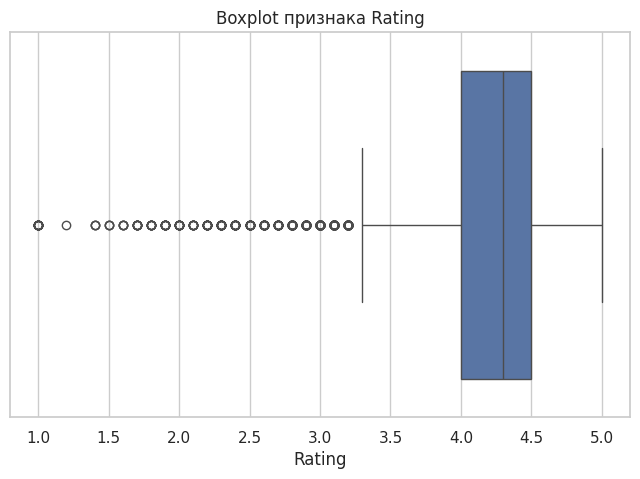

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data["Rating"])
plt.title("Boxplot признака Rating")
plt.show()

# 18. Гистограмма распределения рейтинга

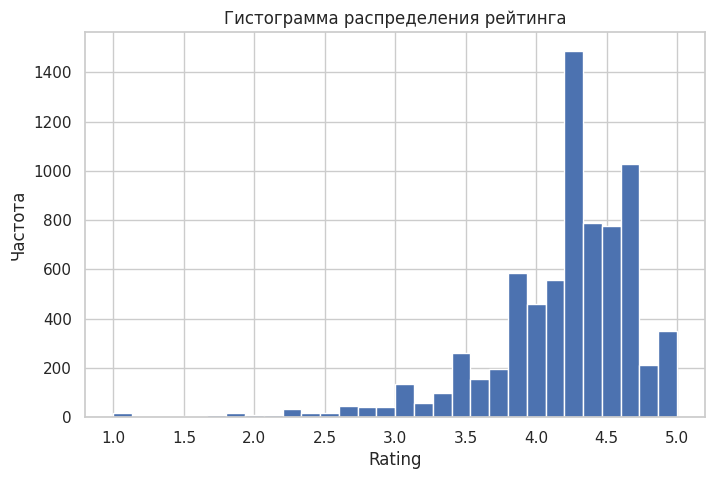

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(data["Rating"], bins=30)
plt.title("Гистограмма распределения рейтинга")
plt.xlabel("Rating")
plt.ylabel("Частота")
plt.show()